#### 简述 Transformer 基本流程
Transformer 是基于自注意力机制的 Seq2Seq 架构，核心分为编码器（Encoder） 和解码器（Decoder） 两部分，完整流程分为 4 个阶段：

***输入预处理阶段***

首先对输入文本做分词得到 token id，通过可学习的 token embedding 层（与transformer联合训练）转化为维度为d_model的向量。token embedding 层先把token id 转换成 V 维（词表大小）的 one-hot 向量，然后过线性层，工程上会直接查表读出权重指定行的向量，减少内存占用并加快处理速度。

embedding层不加激活函数，否则会影响后续Q、K的向量内积，非线性建模交给后续的Transformer。Embedding 层的唯一职责，是给每个 token 提供一个基础的语义向量基底，上下文相关的复杂语义、一词多义、长距离依赖，完全交给后续的多头自注意力层和 FFN 层完成。这样设置也有利于加快计算效率和保持训练稳定性；

由于自注意力具有排列等变性，无法感知序列顺序，因此需要给 embedding 叠加位置编码，注入位置信息。同时对长短不一的序列做 padding 补齐，并在注意力计算时通过 padding mask 屏蔽无效 padding 位的影响，最终按 batch 打包输入模型。

***编码器***

编码器由 N 个完全相同的层堆叠而成，每一层包含两个核心子层，均采用残差连接 + 层归一化结构：

第一子层：多头自注意力层。将输入向量分别通过W_q、W_k、W_v三个权重矩阵投影得到 Q、K、V，将d_model拆分为num_heads × d_k，实现多头拆分；通过softmax( (Q@K^T)/√d_k + mask ) @ V计算自注意力输出，让每个 token 都能聚合全局上下文信息；最后通过线性层融合多头输出。

第二子层：逐位置前馈网络（FFN）。由两个线性层 + 激活函数组成，独立对每个 token 的特征做非线性变换，提升模型的表达能力。

编码器最终输出融合了全局双向上下文信息的语义特征，输入到解码器的交叉注意力层。

***解码器***

解码器同样由 N 个完全相同的层堆叠而成，每一层包含三个核心子层，同样配套残差连接 + 层归一化：

第一子层：带因果掩码的多头自注意力层。和编码器自注意力的核心区别是，训练时会加入上三角因果掩码，屏蔽当前 token 之后的所有位置，防止模型提前看到未来的 token，保证自回归的生成逻辑。

第二子层：交叉注意力层。Q 来自解码器上一层的输出，K、V 来自编码器的最终输出，核心作用是对齐源序列和目标序列的语义信息，让生成的每个 token 都能关注到输入序列的相关内容。

第三子层：FFN 层，和编码器的 FFN 逻辑完全一致。

***输出预测阶段***

解码器的最终输出，通过线性层投影到词表维度，再经 softmax 归一化，得到下一个 token 的概率分布。训练时采用 teacher forcing，一次性输入完整目标序列做并行计算；推理时采用自回归模式，逐个生成 token，将生成的结果拼接到输入中，迭代预测下一个 token。


#### 为什么基于 Transformer 的架构需要多头注意力机制
***突破单头注意力的表达瓶颈***

单头注意力只能学习到序列的一种依赖模式，而多头注意力会将d_model维度的特征拆分为多个独立的子空间，每个注意力头独立在自己的子空间内学习序列的依赖关系，不同的头可以捕捉不同类型的特征：比如有的头学习主谓宾的句法依赖，有的头学习代词和先行词的指代关系，有的头学习短距离的 n-gram 局部特征，有的头学习长距离的上下文依赖，最终让模型的语义编码能力大幅提升。

从空间解释,把注意力的输出想象成空间的一个个点(超几何空间),模型训练的过程，就是学习 Q/K/V 三个投影矩阵的权重 —— 这三个矩阵，本质就是空间平移的规则：决定了怎么计算锚点的权重、往哪个方向平移、平移多少幅度，最终让平移后的点，能让下游任务的损失最小。如果是单头,那就只能调整一个点,变化非常少,如果换成8个头,那就可以在八个低维空间去调整,自由度更高，能更快调整到合适的位置。

***高维空间点积相似度效果差***

当空间维数非常非常大时,向量都非常分散--整个空空间太大了,很难得到两个非常靠近的向量。而attention机制当中,qandk之间的接近性是通过点积得到的。在超高维空间中做点积来获得向量之间的接近性,意义非常小。这样的话,我们就很难得到有意义的attention权重。分成多个head以后,每个head的embedding维数降低。比如、GPT-3是96头,这样每个头只有128维。这样利用向量点积计算向量之间的接近性就有效多了。

***参数量和计算量无额外开销***

多头注意力的总参数量和单头完全一致：单头注意力的 QKV 投影矩阵维度是d_model × d_model，而多头会拆分为num_heads个d_model × d_k的矩阵，其中d_k = d_model / num_heads，总参数量始终是3 × d_model²，不会增加额外开销，属于 “零成本提升模型能力” 的设计。

***提升模型的训练稳定性和泛化性***

多头拆分让模型的注意力学习更具鲁棒性，单个头的学习偏差不会影响整体的输出结果；同时多子空间的特征学习，让模型能更好的泛化到不同的任务和数据分布中，适配翻译、文本生成、理解类等多种 NLP 任务。

#### 什么是旋转位置编码（ROPE）？
核心设计是通过复数域的旋转操作，为 token embedding 注入位置信息，让任意两个 token 的注意力内积只和它们的相对位置差有关，完美适配自注意力的计算逻辑。

***核心原理***

对于位置为m的 token，将它的 embedding 向量两两分组，每一组对应一个复数，对这个复数施加旋转角度m·θ_i，其中θ_i = 10000^(-2(i-1)/d)，i是分组序号，d是 embedding 维度。位置为m和位置为n的两个 token，旋转后的内积结果，只和它们的相对位置差m-n有关，和绝对位置无关。

工程实现：不需要额外的位置 embedding，直接在计算 Q、K 之后，对 Q 和 K 做旋转操作，再计算注意力分数，无需修改模型的其他结构，接入成本极低。

ROPE 的旋转操作只作用于 Q 和 K，不作用于 V，不会影响 V 的特征表达；同时为了适配超长上下文，业界还在 ROPE 的基础上提出了 NTK-aware 缩放、YaRN 等优化方案，进一步提升了长序列外推的效果

***核心优势***

完美适配自注意力机制：自注意力的核心是 Q 和 K 的内积，ROPE 让内积天然携带相对位置信息，完全贴合注意力的计算逻辑；

优秀的长序列外推性：训练时用短序列训练，推理时可以直接扩展到更长的序列，无需额外微调，效果远优于原始 Transformer 的正弦位置编码和可学习位置编码；

兼容线性注意力、稀疏注意力等各类注意力变种，适配性极强。

#### 为什么现在的大模型大多是 decoder-only 的架构

***完美契合缩放定律（Scaling Law）***

> 业界的大量实验证明，decoder-only 架构的模型效果，随着参数量、训练数据量、计算量的增加，呈现出稳定、可预测的幂律增长，模型能力可以通过缩放资源持续提升；而 encoder-decoder 架构的缩放性远不如 decoder-only，随着参数量提升，效果增长会快速进入瓶颈，无法通过简单的资源堆叠实现能力的持续跃升，这是 decoder-only 成为主流的最核心原因。

***训练数据利用率极高***

> decoder-only 采用自回归因果语言建模（CLM） 的预训练目标，输入一段长度为 N 的文本，会生成 N-1 个下一个 token 预测的监督信号，序列中的每一个 token 都能被用于模型训练，数据利用率拉满；而 encoder-decoder 架构的监督信号只有目标序列的长度，源序列无法直接作为生成任务的监督信号，数据利用率极低，在海量语料预训练的场景下，差距被进一步放大。

***预训练 - 微调 - 对齐的全流程范式统一***

> decoder-only 架构的全流程目标完全一致：预训练是自回归的下一个 token 预测，监督微调（SFT）是自回归的指令遵循生成，RLHF/GRPO 等对齐阶段也是基于自回归生成做优化，整个训练链路完全统一，工程实现简单，超参数调优难度低，模型的能力迁移非常顺滑；而 encoder-decoder 架构的预训练目标（掩码语言建模 + 翻译）和微调、对齐的生成目标不一致，能力迁移效果差，对齐难度极高，工程实现复杂度也大幅提升。

***生成任务的适配性拉满***

> 当前大模型的核心应用场景是对话、代码生成、长文本创作等开放式生成任务，decoder-only 的因果自注意力机制，天然适配自回归生成的逻辑，长文本生成的稳定性远优于 encoder-decoder 架构；而 encoder-decoder 架构更适合机器翻译、摘要等有明确源 - 目标对应关系的受限生成任务，无法很好的适配开放式生成场景。

GPT-1 首次验证了 decoder-only 架构在生成任务上的潜力，GPT-3 通过缩放定律验证了 decoder-only 的大模型能力上限

#### ChatGPT 的训练步骤有哪些？

***第一步：无监督预训练（Pre-training）***

>核心目标：让模型获得海量的世界知识和基础的语言生成能力。

>具体做法：以大规模无标注互联网文本、书籍、文章等语料为训练数据，采用因果语言建模（CLM） 的预训练目标，训练一个 decoder-only 的基础模型（Base Model），让模型学会根据上文预测下一个 token。这个阶段的模型具备强大的文本补全能力，但无法遵循人类指令，也没有对齐人类偏好。

***第二步：监督微调（SFT，Supervised Fine-Tuning）***

>核心目标：让模型学会遵循人类的指令，从 “文本补全模型” 转变为 “指令遵循模型”。

>具体做法：人工标注数十万条高质量的 “指令 - 回答” 配对数据，用这些数据以 CLM 目标对基础模型做微调，让模型学会按照人类的指令格式、要求生成对应的回答，而非无差别的补全文本。这个阶段的模型已经可以完成基础的问答、对话任务，但输出的内容不一定符合人类的偏好和价值观。

***第三步：奖励模型训练（RM，Reward Model）***

>核心目标：训练一个可以模拟人类偏好的打分模型，为后续的强化学习提供奖励信号。

>具体做法：针对同一个 prompt，让 SFT 模型生成多个不同的回答，由人工标注员对这些回答按照质量、相关性、安全性、符合人类偏好的程度进行排序；基于这些排序数据，以Pairwise 排序损失训练奖励模型：将 SFT 模型的最后一层线性层替换为输出标量奖励的头部，输入 “prompt + 回答”，输出一个 0~1 的标量奖励值，让模型学会像人类一样对回答质量打分。

***第四步：基于人类反馈的强化学习（RLHF）***

>核心目标：让模型的输出最大化符合人类偏好，完成最终的价值观和能力对齐。

>具体做法：以 SFT 模型为初始策略模型，以训练好的 RM 为奖励函数，采用PPO（近端策略优化） 算法对模型做强化学习优化。模型针对 prompt 生成回答，RM 给出奖励值，同时加入KL 散度约束，限制优化后的模型和初始 SFT 模型的分布差异，防止模型为了迎合奖励出现模式崩溃；通过迭代优化，让模型的输出越来越符合人类的偏好和价值观，最终得到可上线的 ChatGPT 模型。

#### 为什么 Transformer 需要位置编码？
Transformer 必须加入位置编码，核心原因是Transformer 的核心组件自注意力机制，具有排列等变性（Permutation Equivariant），无法感知序列的顺序信息，而自然语言的语义高度依赖 token 的位置和顺序。

#### LLM 的损失函数是什么？给你一个 10w 的词表，怎么计算出损失值？
***LLM 的核心损失函数***

> LLM 在预训练和 SFT 微调阶段，核心损失函数是因果语言建模（CLM）的交叉熵损失（Cross Entropy Loss），工程上通常用稀疏交叉熵实现，避免生成高维 one-hot 向量；在 RLHF/GRPO 等对齐阶段，会额外引入策略损失、价值损失、KL 散度损失等，但预训练和微调的核心始终是交叉熵损失。交叉熵损失的核心目标是：让模型对真实下一个 token 的预测概率最大化，

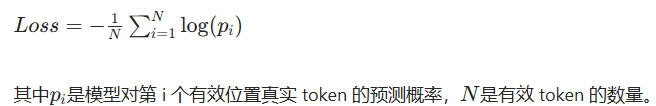

***10w 词表的损失值完整计算步骤***
设定词表大小V=100000，输入 batch size 为B，序列长度为L，模型维度为d_model，完整计算分为 5 步：

> *模型输出投影*

解码器最终输出的张量形状为[B, L, d_model]，通过最终的线性投影层，将d_model维度映射到词表维度V=100000，得到形状为[B, L, 100000]的 logits 张量。工程上，这个线性层的权重通常和 token embedding 层的权重共享，大幅减少模型参数量。

> *标签处理*

标签是输入序列右移一位的 token id，形状为[B, L]，每个元素是 0~99999 之间的整数，对应 10w 词表的 token id。同时生成 padding mask，标记出序列中 padding 的无效位置，这些位置不参与损失计算，避免模型学习无效的 padding 信息。

> *概率归一化*

对 logits 张量的最后一维（词表维度）做 softmax 归一化，得到每个位置、每个 token 的预测概率分布，形状保持[B, L, 100000]，每个位置的 10w 个概率值之和为 1。

> *有效位置的概率提取*

对每个有效位置（非 padding），根据标签中的 token id，提取出模型对该真实 token 的预测概率p i，过滤掉所有 padding 位置的无效值。

> *损失值计算*

对所有有效位置的p i，取对数、取负数，然后求平均值，得到最终的交叉熵损失值。工程上为了数值稳定性，会直接用 logits 计算稀疏交叉熵，不单独做 softmax，避免数值下溢。

#### 介绍一下 DeepSeek 里面的 MLA 注意力，以及它的 KV-Cache 怎么做的
***MLA 的核心原理***

传统的 MHA/GQA/MQA，都需要为每个 token 存储独立的 K 和 V 向量，长序列推理时，KV-Cache 的显存占用会随着序列长度线性增长，成为推理的核心瓶颈。MLA 的核心创新是将 KV 的特征压缩到共享的低维隐空间，解耦 KV 的存储和计算，从根源上降低 KV-Cache 的显存占用。
核心设计分为 3 点：

KV 的隐空间压缩与解耦

> MLA 不再为每个注意力头单独生成 K 和 V，而是先将输入的隐状态通过一个线性层，压缩得到低维的共享隐状态 V_Latent，维度远小于d_model，且所有注意力头共享这个隐状态。K 不再直接从输入投影生成，而是从 V_Latent 中通过线性层实时投影得到；V 也从 V_Latent 中投影得到。这样，KV 的核心信息都被压缩到了低维的 V_Latent 中，无需存储高维的 K 和 V。

ROPE 的适配设计

>为了避免 ROPE 的旋转操作破坏隐空间的矩阵融合，MLA 将 Q 拆分为两个部分：一部分是Q_rope，专门做 ROPE 旋转，注入相对位置信息；另一部分是Q_latent，和从 V_Latent 投影出的 K_latent 计算注意力分数，二者最终拼接后完成注意力计算，既保留了 ROPE 的位置编码能力，又不影响隐空间的压缩和矩阵融合。

零开销的矩阵融合技巧

>MLA 通过矩阵运算的结合律，将 K 的投影矩阵和 Q 的投影矩阵融合为一个矩阵，将 V 的投影矩阵和注意力输出的线性层融合，原本需要多次的矩阵乘法，被合并为单次计算，不仅没有增加额外的计算开销，反而减少了计算量，实现了 “显存降低 + 速度提升” 的双赢。

***MLA 的 KV-Cache 优化方案***

传统的 KV-Cache，每生成一个 token，就需要存储当前 token 的 K 和 V，下一次计算时，将历史 KV 和当前 KV 拼接后计算注意力，显存占用为：2×B×S×num_heads×d_k×L_layers。

MLA 对 KV-Cache 做了颠覆性的优化：

>KV-Cache 只存储低维的 V_Latent:
MLA 的 KV-Cache 不再存储高维的 K 和 V，只需要存储每个 token 对应的低维共享 V_Latent，无需存储 K，因为 K 可以在每次计算时，从缓存的 V_Latent 中实时投影出来。比如传统 MHA 的 KV 维度是 512，MLA 的 V_Latent 维度可以压缩到 128，显存占用直接降低 75% 以上；同时 V_Latent 是所有头共享的，无需为每个头单独存储，进一步降低了显存开销。

>KV-Cache 的读写逻辑不变，工程适配成本极低:
MLA 的 KV-Cache 依然遵循 “增量存储、拼接计算” 的逻辑，每生成一个 token，就将当前的 V_Latent 追加到缓存中，下一次计算时，直接读取整个缓存的 V_Latent，投影出 K 和 V 后计算注意力，和传统 KV-Cache 的工程逻辑完全兼容，适配成本极低。

>长序列场景的优势被无限放大:
随着序列长度的增加，KV-Cache 的显存占比会超过模型本身的权重，MLA 的显存优化效果会越来越明显。DeepSeek-V2 基于 MLA，实现了 128k 上下文窗口的高效推理，在相同显存下，支持的序列长度是传统 MHA 的 4 倍以上，同时推理速度提升 30% 以上。

#### 讲一下 GRPO 算法，相比 PPO 做了哪几点改进？

GRPO（Group Relative Policy Optimization，分组相对策略优化）是 DeepSeek 在 DeepSeek-R1 推理模型中提出的强化学习算法，专门针对大语言模型的生成式强化学习场景设计，解决了传统 PPO 算法在 LLM 对齐中训练不稳定、工程复杂度高、显存开销大、复现难度高等核心痛点，也是当前开源推理大模型的主流对齐算法。

***先明确 PPO 在 LLM 场景的核心痛点***

PPO 是 Actor-Critic 架构，需要同时训练策略模型（Actor）和价值模型（Critic），Critic 负责估计状态价值，计算优势函数指导 Actor 更新。在 LLM 场景中，PPO 有 4 个核心痛点：

>训练不稳定：Actor 和 Critic 需要交替训练，Critic 的价值估计偏差会直接导致 Actor 更新失效，甚至出现模式崩溃；

>显存和计算开销极大：Critic 通常和 Actor 同参数量，显存占用直接翻倍，训练速度大幅降低；

>超参数敏感：KL 散度约束、优势估计、学习率等超参数需要精细调优，否则极易出现训练失效；

>工程复现难度高：需要维护经验回放池、GAE 优势估计、双模型更新等复杂逻辑，代码实现难度大，很难复现论文效果。

***GRPO 相比 PPO 的核心改进（面试分点作答，逻辑更清晰）***

>核心改进 1：完全舍弃 Critic 价值网络，用分组相对优势替代绝对价值估计

这是 GRPO 最颠覆性的改进。GRPO 针对同一个 prompt，并行采样 N 个不同的回答（一个 Group），通过奖励模型 / 规则奖励函数为每个回答打分，得到奖励r_i​，然后计算分组内的奖励均值μ和标准差σ，用相对优势A_i=(r_i−μ)/σ 替代 PPO 中 Critic 估计的优势函数。

解决的痛点：无需训练 Critic 网络，显存和计算开销直接减半，同时彻底避免了 Critic 价值估计不准导致的训练不稳定问题，训练鲁棒性大幅提升。

>核心改进 2：天然的分布约束，无需复杂的 KL 散度超参数调优

PPO 需要手动设置 KL 散度惩罚项的权重，约束优化后的策略和初始 SFT 模型的分布差异，防止模式崩溃，但权重设置极难平衡：权重太小会出现模式崩溃，权重太大会导致策略学不到东西。
GRPO 采用分组内的相对优势更新，只有比组内平均表现好的样本才会被正向强化，表现差的样本会被负向抑制，天然的约束了策略的更新幅度，无需额外的 KL 散度惩罚项（仅需极弱的约束），彻底解决了 PPO 超参数敏感的问题，训练流程大幅简化。

>核心改进 3：逐 token 的细粒度奖励分配，更适配推理类任务

PPO 的优势函数是针对整个序列的全局估计，对每个 token 的优化信号是相同的，无法很好的适配数学推理、代码生成等长链推理任务 —— 这类任务的奖励是全局的（答案对 / 错），需要所有 token 都学习到这个全局信号。
GRPO 将整个回答的全局相对优势，分配到序列中的每一个生成 token 上，每个 token 的更新都对应全局的奖励信号，实现了更细粒度的策略优化，大幅提升了模型的长链推理能力，这也是 DeepSeek-R1 用 GRPO 后，数学推理能力大幅跃升的核心原因。

>核心改进 4：工程实现极简，复现和落地成本极低

PPO 需要维护 Actor、Critic 双模型，还要实现经验回放、GAE、双模型交替更新等复杂逻辑，代码量极大，超参数多，工业界落地难度高。
GRPO 只需要一个策略模型，无需经验回放池，无需 Critic 训练，核心逻辑只有 “分组采样 - 奖励计算 - 相对优势计算 - 裁剪策略更新” 四步，代码量只有 PPO 的 1/5，超参数极少，极易复现和落地，非常适合开源社区和工业界的快速迭代。

#### 通过训练的 loss 曲线能看出对 GRPO 或者 PPO 的效果吗？

无法直接通过 loss 曲线判断 GRPO/PPO 训练后模型的最终效果（推理能力、人类偏好对齐程度等），但 loss 曲线可以有效反映训练过程的稳定性和收敛性，辅助判断训练流程是否正常，是重要的训练监控指标，而非效果评估指标。

***一、为什么 loss 曲线无法直接判断模型效果***

loss 的优化目标和模型的最终效果目标不一致：PPO 和 GRPO 的 loss，优化的是策略的更新方向，而非模型的最终能力。

>PPO 的 loss 由三部分组成：策略裁剪损失、价值损失、KL 散度损失。策略损失下降，只代表策略的输出越来越向 “优势高的动作” 靠拢，但如果 Critic 的优势估计不准、奖励模型有偏，loss 下降反而会导致模型出现 “奖励黑客” 现象 —— 学会迎合奖励模型的偏好，而非真正提升推理能力或对齐人类偏好，甚至出现模式崩溃，loss 趋近于 0，但模型效果完全失效。价值损失下降，只代表 Critic 对价值的估计越来越准，和策略模型的效果没有直接关系。

>GRPO 的 loss 是基于分组相对优势的策略裁剪损失，loss 下降，只代表策略越来越倾向于生成分组内奖励高的样本，但如果分组采样的多样性不足、奖励信号有偏，loss 下降反而会导致模型泛化性变差，只会输出固定的内容，而非真正的能力提升。
模型效果是离线的、多维度的，和在线训练的 loss 没有线性对应关系

>PPO/GRPO 训练的目标，是提升模型的推理能力、人类偏好对齐程度、安全性等，这些指标都需要通过离线基准测试、人工评分等方式评估，是离线的、多维度的；而 loss 是在线训练过程中的单维度指标，两者之间没有直接的线性对应关系。

实际训练中，经常出现两种情况：

>loss 曲线平稳下降，但模型的 MMLU、GSM8K 等基准测试分数不升反降，模型出现了过拟合，只会迎合奖励模型，而非真正提升能力；

>loss 曲线有合理的波动，但模型的基准测试分数持续提升，因为策略在探索更优的输出，而非过度拟合当前的奖励信号。

>loss 的数值受超参数影响极大，没有统一的评估标准

PPO/GRPO 的 loss 数值，受学习率、裁剪阈值、奖励缩放、分组大小等超参数的影响极大，不同超参数下的 loss 数值完全没有可比性，无法通过 loss 的绝对值或下降幅度，判断模型的效果好坏。

***二、loss 曲线的实际作用***

loss 曲线是核心的训练过程监控指标，可以快速判断训练是否正常：

>如果 loss 曲线出现剧烈震荡、持续发散，说明训练不稳定，超参数设置不合理，需要调整；

>如果 loss 曲线快速下降到 0 并保持不变，说明模型出现了模式崩溃，策略更新幅度太大，只会输出固定的内容，训练已经失效；

>如果 loss 曲线长时间平稳不动，说明策略没有学到有效的奖励信号，可能是奖励函数设计不合理、优势计算有问题，需要重新设计训练方案。

***三、真正判断 PPO/GRPO 训练效果的方法***

必须通过多维度的离线评测，才能准确判断模型的效果，核心分为三类：

>能力基准测试：用 MMLU、CMMLU 等通用知识基准，GSM8K、MATH 等数学推理基准，HumanEval、MBPP 等代码基准，测试模型的基础能力；

>对齐能力评测：用 MT-Bench、Arena Hard 等对话对齐基准，配合人工评分，测试模型的人类偏好对齐程度、安全性、对话流畅度；

>针对性任务评测：针对模型的落地场景，设计专属的测试集，比如客服场景的客服对话测试集，代码场景的业务代码测试集，测试模型的落地效果。